# Project FORESIGHT – AI-Powered Demand & Inventory Intelligence Platform
# Store Item Demand Forecasting Challenge

### 1. Project Overview

** Project FORESIGHT – AI-Powered Demand & Inventory Intelligence Platform** is a machine learning-based demand forecasting solution designed to help businesses make better inventory planning and supply chain decisions.

The project uses historical sales and product-related data to analyze demand patterns and build a forecasting model that predicts future product demand. The solution follows an end-to-end data science workflow, including data understanding, preprocessing, exploratory data analysis, feature engineering, model training, model evaluation, and demand prediction.

The trained model is applied to the test dataset to generate future demand predictions. These predictions can then be used to identify potential **stockout and overstock risks**, helping businesses plan inventory levels more effectively.

The main objective of Project FORESIGHT is to combine **machine learning, demand forecasting, and inventory intelligence** to support data-driven decision-making, reduce unnecessary inventory costs, minimize the risk of product shortages, and improve overall inventory planning.

### Key Objectives

* Analyze historical sales and demand patterns.
* Perform data preprocessing and exploratory data analysis.
* Develop relevant features for demand forecasting.
* Train and evaluate a machine learning model.
* Predict future demand for products.
* Identify potential stockout and overstock situations.
* Generate actionable inventory planning insights.
* Create a structured prediction output for further analysis or dashboard integration.

### Technology Used

* **Python**
* **Pandas & NumPy**
* **Matplotlib & Seaborn**
* **Scikit-learn**
* **Jupyter Notebook**
* **Machine Learning**
* **Demand Forecasting**


## Import Required Libraries

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.ensemble import RandomForestRegressor

# Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


##  Load the Datasets

In [3]:
# Load all datasets

train = pd.read_csv(r"C:\Users\shrey\Downloads\demand-forecasting-kernels-only\train.csv")
test = pd.read_csv(r"C:\Users\shrey\Downloads\demand-forecasting-kernels-only\test.csv")
sample_submission = pd.read_csv(r"C:\Users\shrey\Downloads\demand-forecasting-kernels-only\sample_submission.csv")

print("All datasets loaded successfully!")
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample Submission shape:", sample_submission.shape)

All datasets loaded successfully!
Train shape: (913000, 4)
Test shape: (45000, 4)
Sample Submission shape: (45000, 2)


In [4]:
# Display first 10 rows of each dataset

print("TRAIN DATASET")
display(train.head(10))

print("TEST DATASET")
display(test.head(10))

print("SAMPLE SUBMISSION DATASET")
display(sample_submission.head(10))

TRAIN DATASET


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
5,2013-01-06,1,1,12
6,2013-01-07,1,1,10
7,2013-01-08,1,1,9
8,2013-01-09,1,1,12
9,2013-01-10,1,1,9


TEST DATASET


,id,date,store,item
0,0,2018-01-01,1,1
1,1,2018-01-02,1,1
2,2,2018-01-03,1,1
3,3,2018-01-04,1,1
4,4,2018-01-05,1,1
5,5,2018-01-06,1,1
6,6,2018-01-07,1,1
7,7,2018-01-08,1,1
8,8,2018-01-09,1,1
9,9,2018-01-10,1,1


SAMPLE SUBMISSION DATASET


,id,sales
0,0,52
1,1,52
2,2,52
3,3,52
4,4,52
5,5,52
6,6,52
7,7,52
8,8,52
9,9,52


##  Data Cleaning

In [5]:
# Check dataset information

print("TRAIN DATA INFORMATION")
train.info()

print("\nTEST DATA INFORMATION")
test.info()

print("\nSAMPLE SUBMISSION INFORMATION")
sample_submission.info()

TRAIN DATA INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB

TEST DATA INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      45000 non-null  int64 
 1   date    45000 non-null  object
 2   store   45000 non-null  int64 
 3   item    45000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.4+ MB

SAMPLE SUBMISSION INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  ----------

In [6]:
# Check missing values

print("Missing values in TRAIN:")
display(train.isnull().sum())

print("\nMissing values in TEST:")
display(test.isnull().sum())

print("\nMissing values in SAMPLE SUBMISSION:")
display(sample_submission.isnull().sum())


Missing values in TRAIN:


date     0
store    0
item     0
sales    0
dtype: int64


Missing values in TEST:


id       0
date     0
store    0
item     0
dtype: int64


Missing values in SAMPLE SUBMISSION:


id       0
sales    0
dtype: int64

In [7]:
# Check duplicate rows

print("Duplicate rows in TRAIN:", train.duplicated().sum())
print("Duplicate rows in TEST:", test.duplicated().sum())
print("Duplicate rows in SAMPLE SUBMISSION:", sample_submission.duplicated().sum())

Duplicate rows in TRAIN: 0
Duplicate rows in TEST: 0
Duplicate rows in SAMPLE SUBMISSION: 0


In [8]:
# Statistical summary

display(train.describe(include="all"))

,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
unique,1826,NaN,NaN,NaN
top,2013-01-01,NaN,NaN,NaN
freq,500,NaN,NaN,NaN
mean,NaN,5.500000,25.500000,52.250287
std,NaN,2.872283,14.430878,28.801144
min,NaN,1.000000,1.000000,0.000000
25%,NaN,3.000000,13.000000,30.000000
50%,NaN,5.500000,25.500000,47.000000
75%,NaN,8.000000,38.000000,70.000000


In [9]:
# Check duplicate records

print("Duplicate rows in TRAIN:", train.duplicated().sum())
print("Duplicate rows in TEST:", test.duplicated().sum())
print("Duplicate rows in SAMPLE SUBMISSION:", sample_submission.duplicated().sum())

Duplicate rows in TRAIN: 0
Duplicate rows in TEST: 0
Duplicate rows in SAMPLE SUBMISSION: 0


In [10]:
# Check duplicate combinations of date, store and item

train_duplicates = train.duplicated(subset=["date", "store", "item"]).sum()
test_duplicates = test.duplicated(subset=["date", "store", "item"]).sum()

print("Duplicate date-store-item combinations in TRAIN:", train_duplicates)
print("Duplicate date-store-item combinations in TEST:", test_duplicates)

Duplicate date-store-item combinations in TRAIN: 0
Duplicate date-store-item combinations in TEST: 0


In [11]:
# Convert date columns to datetime

train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])

print("Train date range:", train["date"].min(), "to", train["date"].max())
print("Test date range:", test["date"].min(), "to", test["date"].max())

print("\nTrain date dtype:", train["date"].dtype)
print("Test date dtype:", test["date"].dtype)

Train date range: 2013-01-01 00:00:00 to 2017-12-31 00:00:00
Test date range: 2018-01-01 00:00:00 to 2018-03-31 00:00:00

Train date dtype: datetime64[ns]
Test date dtype: datetime64[ns]


In [12]:
# Check sales statistics

print("Minimum sales:", train["sales"].min())
print("Maximum sales:", train["sales"].max())
print("Average sales:", train["sales"].mean())
print("Median sales:", train["sales"].median())

print("\nNegative sales values:", (train["sales"] < 0).sum())

Minimum sales: 0
Maximum sales: 231
Average sales: 52.250286966046005
Median sales: 47.0

Negative sales values: 0


##  Exploratory Data Analysis (EDA)

## Dataset Summary

In [13]:
# Basic summary of the training dataset

print("Number of records:", len(train))
print("Number of stores:", train["store"].nunique())
print("Number of items:", train["item"].nunique())
print("Date range:", train["date"].min(), "to", train["date"].max())

display(train[["store", "item", "sales"]].describe())

Number of records: 913000
Number of stores: 10
Number of items: 50
Date range: 2013-01-01 00:00:00 to 2017-12-31 00:00:00


,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


# Total Sales by Store

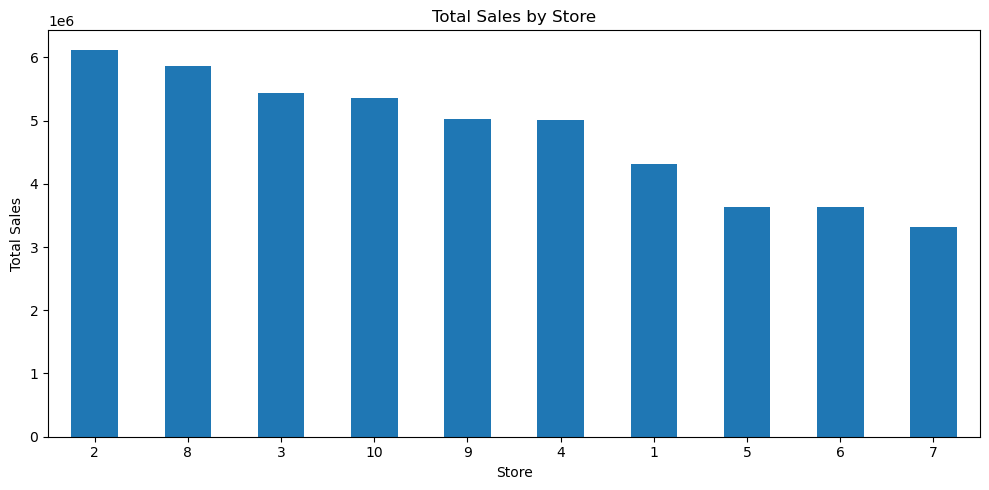

In [14]:
store_sales = train.groupby("store")["sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
store_sales.plot(kind="bar")
plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Insight
The analysis shows noticeable differences in total sales across stores. Store 2 has the highest overall sales, while Store 7 has the lowest. 
This indicates that demand varies by store, making store-level information an important feature for demand forecasting and inventory planning. 
Higher-demand stores may require greater inventory availability,while lower-demand stores may require more controlled stock levels.

## Sales Distribution by Store

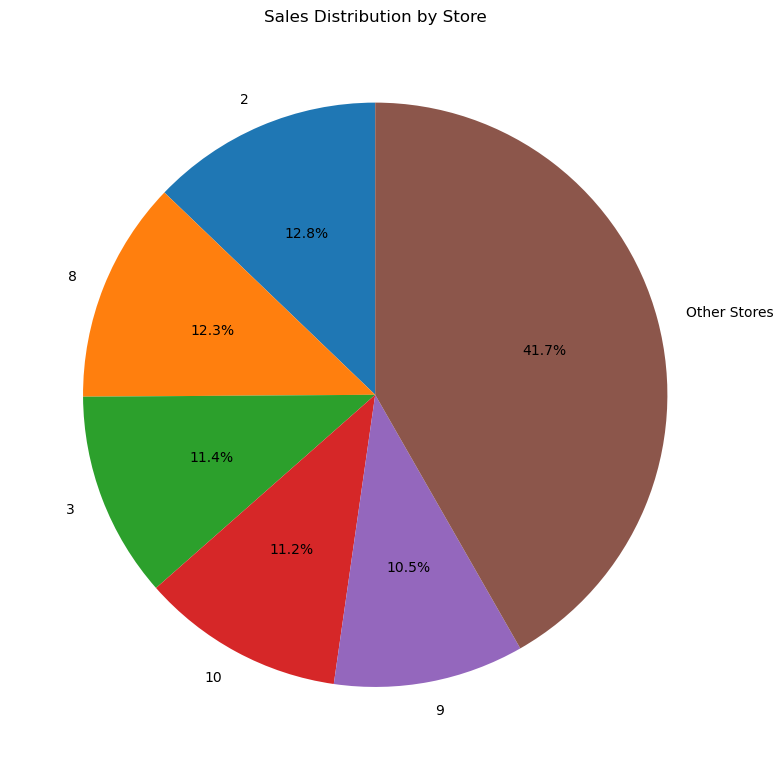

In [15]:
# Calculate total sales by store
store_sales = train.groupby("store")["sales"].sum().sort_values(ascending=False)

# Keep top 5 stores and combine remaining stores
top_5 = store_sales.head(5)
other_sales = store_sales.iloc[5:].sum()

pie_data = pd.concat([top_5,pd.Series({"Other Stores": other_sales})])

# Pie chart
plt.figure(figsize=(8, 8))
plt.pie(pie_data.values,labels=pie_data.index,autopct="%1.1f%%",startangle=90)

plt.title("Sales Distribution by Store")
plt.tight_layout()
plt.show()

## Insight
Store 2 contributes the highest share of total sales among the individual stores, accounting for approximately 12.8% of total sales. Store 8 contributes 12.3%, while Store 3 contributes 11.4%. The remaining stores together account for approximately 41.7% of total sales. This indicates that sales are distributed across multiple stores, with some stores generating relatively higher demand. Therefore, store-level information should be retained as an important feature during demand forecasting and inventory planning.

### Monthly Sales Trend

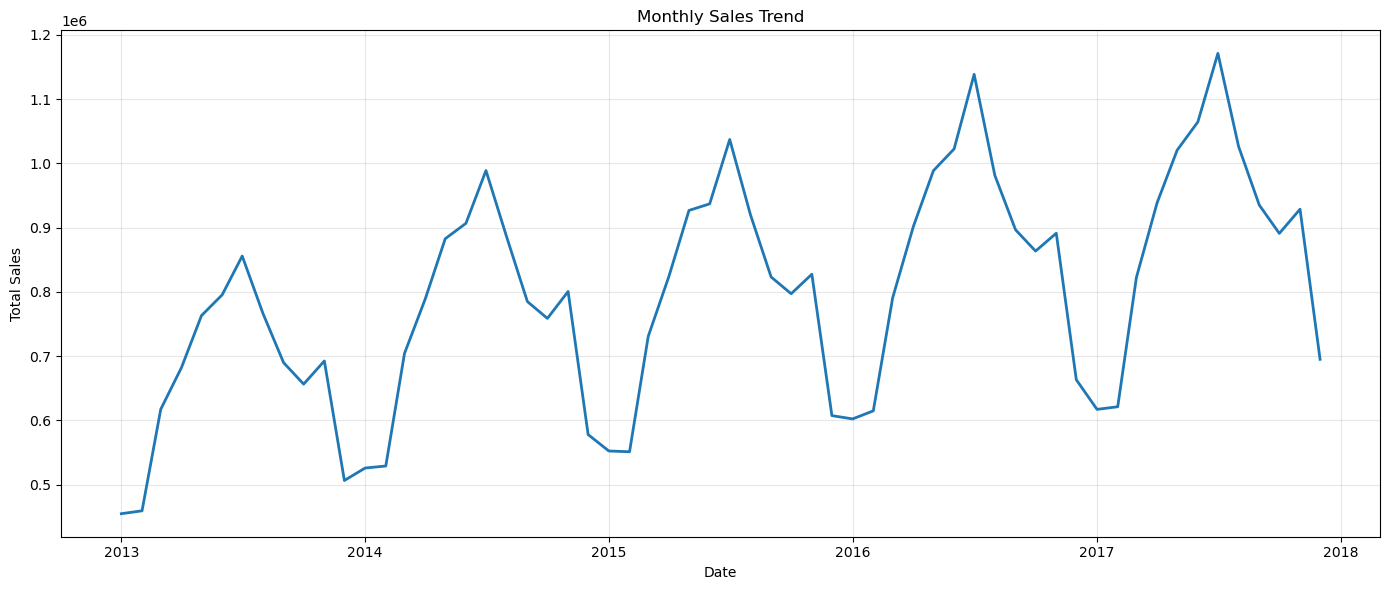

In [16]:
# Calculate monthly total sales
monthly_sales = (train.groupby(train["date"].dt.to_period("M"))["sales"].sum())

# Convert Period to timestamp for plotting
monthly_sales.index = monthly_sales.index.to_timestamp()
plt.figure(figsize=(14, 6))
plt.plot(monthly_sales.index, monthly_sales.values,linewidth=2)
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

 # Insight: 
The monthly sales trend shows a clear repeating seasonal pattern across the years. 
Sales generally increase during the middle of each year, reach a peak around the middle of the year, and then decline toward the end of the year. 
The overall level of sales also increases over time, with the highest peak occurring in 2017. 
This indicates that demand is influenced by both seasonality and long-term growth. 
Therefore, time-based features such as year, month, and day-of-week will be important for the demand forecasting model.

### Correlation Analysis

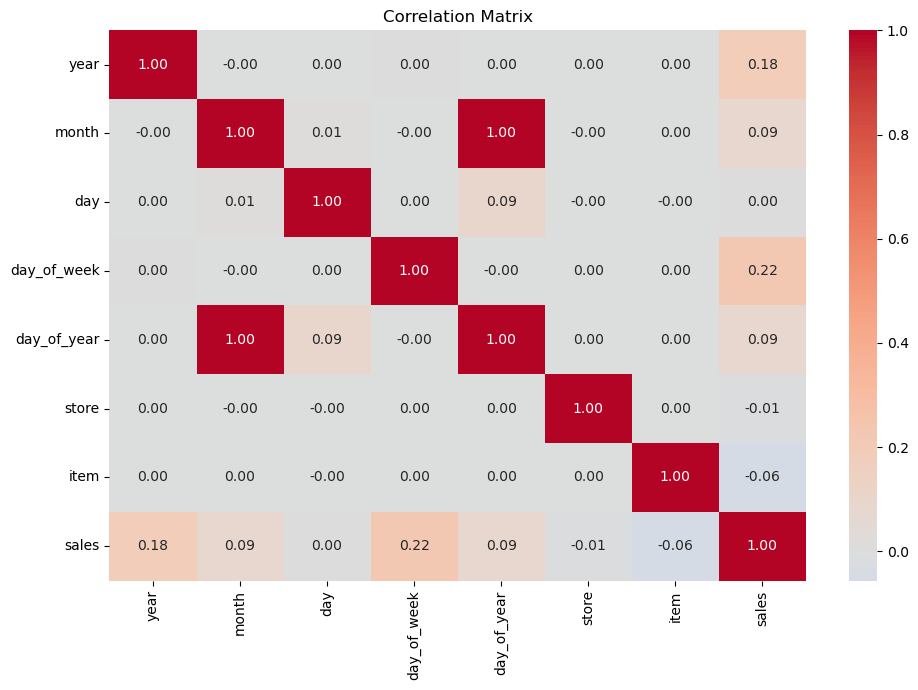

In [17]:
# Create time-based features for correlation analysis

corr_data = train.copy()

corr_data["year"] = corr_data["date"].dt.year
corr_data["month"] = corr_data["date"].dt.month
corr_data["day"] = corr_data["date"].dt.day
corr_data["day_of_week"] = corr_data["date"].dt.dayofweek
corr_data["day_of_year"] = corr_data["date"].dt.dayofyear

# Select numeric columns
correlation = corr_data[ ["year", "month", "day", "day_of_week","day_of_year", "store", "item", "sales"]].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(correlation,annot=True,fmt=".2f",cmap="coolwarm",center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Average Sales by Day of Week

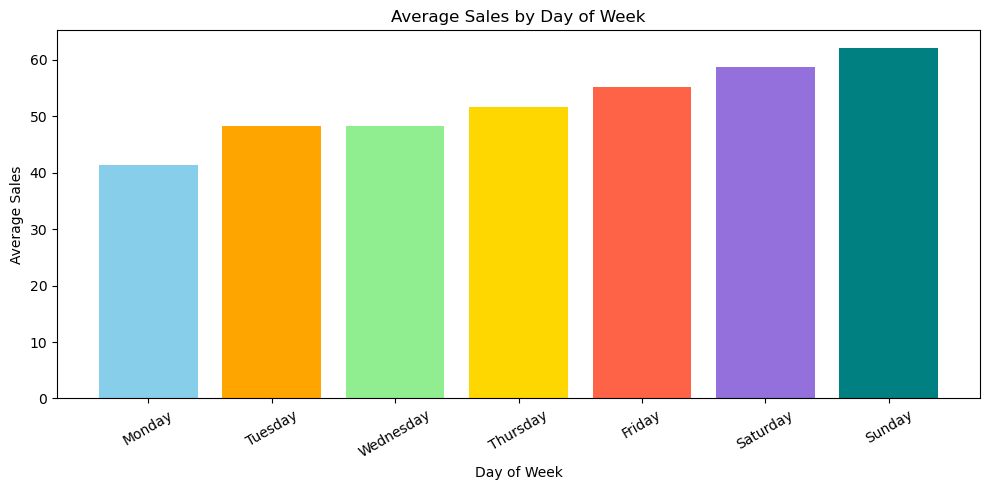

In [19]:
day_order = ["Monday", "Tuesday", "Wednesday","Thursday", "Friday", "Saturday", "Sunday"]
day_sales = (train.groupby(train["date"].dt.day_name())["sales"].mean().reindex(day_order))
# Colors for each day
colors = ["skyblue","orange", "lightgreen", "gold","tomato","mediumpurple", "teal"]
plt.figure(figsize=(10, 5))
plt.bar(day_sales.index,day_sales.values,color=colors)

plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# Insight — 

Average sales show a clear weekly pattern. Sunday has the highest average sales (approximately 62 units), followed by Saturday (around 59 units)
and Friday (around 55 units). Monday has the lowest average sales (around 41 units). Overall, average sales tend to increase from the 
beginning of the week toward the weekend. This indicates that day-of-week is an important demand pattern and should be included 
as a feature in the forecasting model.

##  Feature Engineering

In [21]:
###  Create Date-Based Features
# Create a copy of the datasets
train_model = train.copy()
test_model = test.copy()

# Extract date-based features
for df in [train_model, test_model]:
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["day_of_week"] = df["date"].dt.dayofweek
    df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
    df["day_of_year"] = df["date"].dt.dayofyear
    df["quarter"] = df["date"].dt.quarter

print("Feature engineering completed.")

Feature engineering completed.


In [22]:
###  Check Engineered Features
display(train_model.head())

,date,store,item,sales,year,month,day,day_of_week,week_of_year,day_of_year,quarter
0,2013-01-01,1,1,13,2013,1,1,1,1,1,1
1,2013-01-02,1,1,11,2013,1,2,2,1,2,1
2,2013-01-03,1,1,14,2013,1,3,3,1,3,1
3,2013-01-04,1,1,13,2013,1,4,4,1,4,1
4,2013-01-05,1,1,10,2013,1,5,5,1,5,1


In [23]:
# Separate target variable
X = train_model.drop(columns=["sales", "date"])
y = train_model["sales"]

# Test features
X_test = test_model.drop(columns=["id", "date"])

print("Training features shape:", X.shape)
print("Target shape:", y.shape)
print("Test features shape:", X_test.shape)

Training features shape: (913000, 9)
Target shape: (913000,)
Test features shape: (45000, 9)


In [24]:
# Sort training data chronologically
train_model = train_model.sort_values("date").reset_index(drop=True)

# Use the last 20% as validation data
split_index = int(len(train_model) * 0.8)

train_data = train_model.iloc[:split_index]
valid_data = train_model.iloc[split_index:]

# Features
X_train = train_data.drop(columns=["sales", "date"])
y_train = train_data["sales"]

X_valid = valid_data.drop(columns=["sales", "date"])
y_valid = valid_data["sales"]

print("Training data:", X_train.shape)
print("Validation data:", X_valid.shape)

print("\nTraining period:")
print(train_data["date"].min(), "to", train_data["date"].max())

print("\nValidation period:")
print(valid_data["date"].min(), "to", valid_data["date"].max())

Training data: (730400, 9)
Validation data: (182600, 9)

Training period:
2013-01-01 00:00:00 to 2016-12-31 00:00:00

Validation period:
2016-12-31 00:00:00 to 2017-12-31 00:00:00


##
Since this is a demand forecasting problem, I used a chronological train-validation split instead of a random split.
The model learns from earlier dates and is evaluated on later dates, which better represents real-world forecasting.

##  Model Training
##  Train Random Forest Regressor

In [27]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
model = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train the model
model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


# Model Evaluation

In [28]:
# Predict on validation data
y_pred = model.predict(X_valid)

print("Validation predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Validation predictions generated successfully!
Number of predictions: 182600


In [29]:
# Predict on validation data
y_pred = model.predict(X_valid)

print("Validation predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Validation predictions generated successfully!
Number of predictions: 182600


In [30]:
###  Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_valid, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
r2 = r2_score(y_valid, y_pred)

print("Model Performance")
print("-" * 30)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Model Performance
------------------------------
MAE  : 10.93
RMSE : 16.35
R²   : 0.7313


In [31]:
### 8.3 Actual vs Predicted Sales
comparison = pd.DataFrame({ "Actual Sales": y_valid.values,"Predicted Sales": y_pred})
display(comparison.head(20))

,Actual Sales,Predicted Sales
0,23,27.521378
1,31,39.693389
2,63,41.510975
3,48,56.388287
4,34,29.261189
5,55,57.010941
6,97,95.241242
7,83,87.782642
8,65,57.747650
9,37,30.271616


##  Final Model Training
###  Prepare Complete Training Data

In [32]:
# Prepare complete training features and target

X_full = train_model.drop(columns=["sales", "date"])
y_full = train_model["sales"]

print("Full training features:", X_full.shape)
print("Full target:", y_full.shape)

Full training features: (913000, 9)
Full target: (913000,)


###  Train Final Random Forest Model

In [33]:
# Train final model using all available training data
final_model = RandomForestRegressor(n_estimators=50, max_depth=15, min_samples_leaf=2,random_state=42,n_jobs=-1)
final_model.fit(X_full, y_full)
print("Final model trained successfully!")

Final model trained successfully!


##  Generate Predictions
###  Predict Demand for Test Data

In [35]:
# Generate predictions for test dataset

test_predictions = final_model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(test_predictions))

display(test_predictions[:10])

Predictions generated successfully!
Number of predictions: 45000


array([14.64330037, 13.26739657, 14.3049904 , 14.55823033, 19.91833333,
       18.874     , 21.57109524, 15.07928251, 13.33342397, 13.61822613])

##  Create Submission File
###  Prepare Submission Format

In [37]:
# Create a copy of the sample submission
submission = sample_submission.copy()

# Add model predictions
submission["sales"] = test_predictions

# Ensure sales predictions are non-negative
submission["sales"] = submission["sales"].clip(lower=0)

# Round predictions because sales represents demand units
submission["sales"] = submission["sales"].round().astype(int)

display(submission.head(10))

,id,sales
0,0,15
1,1,13
2,2,14
3,3,15
4,4,20
5,5,19
6,6,22
7,7,15
8,8,13
9,9,14


In [38]:
###  Verify Submission File
print("Submission shape:", submission.shape)
print("Submission columns:", submission.columns.tolist())

print("\nMissing values:")
print(submission.isnull().sum())

display(submission.head())

Submission shape: (45000, 2)
Submission columns: ['id', 'sales']

Missing values:
id       0
sales    0
dtype: int64


,id,sales
0,0,15
1,1,13
2,2,14
3,3,15
4,4,20


In [39]:
# Save final prediction file
submission.to_csv("foresight_predictions.csv", index=False)

print("Final prediction file saved successfully!")
print("File name: foresight_predictions.csv")

Final prediction file saved successfully!
File name: foresight_predictions.csv


In [40]:
# Verify saved file

final_submission = pd.read_csv("foresight_predictions.csv")

print("Final file shape:", final_submission.shape)
display(final_submission.head(10))

Final file shape: (45000, 2)


,id,sales
0,0,15
1,1,13
2,2,14
3,3,15
4,4,20
5,5,19
6,6,22
7,7,15
8,8,13
9,9,14


##  Inventory Risk Analysis
# Create Forecast Results

In [41]:
# Create forecast results

forecast_results = test.copy()

forecast_results["predicted_sales"] = test_predictions

# Make predictions non-negative
forecast_results["predicted_sales"] = forecast_results["predicted_sales"].clip(lower=0)

# Round predicted demand
forecast_results["predicted_sales"] = forecast_results["predicted_sales"].round().astype(int)

display(forecast_results.head(10))

,id,date,store,item,predicted_sales
0,0,2018-01-01,1,1,15
1,1,2018-01-02,1,1,13
2,2,2018-01-03,1,1,14
3,3,2018-01-04,1,1,15
4,4,2018-01-05,1,1,20
5,5,2018-01-06,1,1,19
6,6,2018-01-07,1,1,22
7,7,2018-01-08,1,1,15
8,8,2018-01-09,1,1,13
9,9,2018-01-10,1,1,14


###  Identify High-Demand Products

In [43]:
high_demand = (forecast_results.groupby("item")["predicted_sales"] .mean().sort_values(ascending=False))
print("Top 10 items by predicted average demand:")
display(high_demand.head(10))

Top 10 items by predicted average demand:


item
15    76.697778
13    73.161111
18    72.953333
45    69.596667
38    69.188889
8     66.315556
22    65.590000
36    61.731111
10    61.601111
11    60.764444
Name: predicted_sales, dtype: float64

In [44]:
### 13.3 Store-Level Predicted Demand
store_demand = (forecast_results.groupby("store")["predicted_sales"].mean().sort_values(ascending=False))
display(store_demand)

store
2     51.612000
8     50.975556
3     47.845556
10    47.843111
9     47.050889
4     46.716889
1     41.286444
5     36.110667
6     35.963556
7     34.897778
Name: predicted_sales, dtype: float64

 ## Inventory Recommendations

In [45]:
# Calculate demand thresholds
low_threshold = forecast_results["predicted_sales"].quantile(0.33)
high_threshold = forecast_results["predicted_sales"].quantile(0.67)

def inventory_recommendation(sales):
    if sales <= low_threshold:
        return "Low Demand"
    elif sales <= high_threshold:
        return "Medium Demand"
    else:
        return "High Demand"

forecast_results["inventory_recommendation"] = (
    forecast_results["predicted_sales"]
    .apply(inventory_recommendation)
)

display(forecast_results.head(10))

,id,date,store,item,predicted_sales,inventory_recommendation
0,0,2018-01-01,1,1,15,Low Demand
1,1,2018-01-02,1,1,13,Low Demand
2,2,2018-01-03,1,1,14,Low Demand
3,3,2018-01-04,1,1,15,Low Demand
4,4,2018-01-05,1,1,20,Low Demand
5,5,2018-01-06,1,1,19,Low Demand
6,6,2018-01-07,1,1,22,Low Demand
7,7,2018-01-08,1,1,15,Low Demand
8,8,2018-01-09,1,1,13,Low Demand
9,9,2018-01-10,1,1,14,Low Demand


In [46]:
###  Demand Category Distribution
demand_distribution = (
    forecast_results["inventory_recommendation"]
    .value_counts()
)

display(demand_distribution)

inventory_recommendation
Medium Demand    15257
Low Demand       15225
High Demand      14518
Name: count, dtype: int64

In [47]:
###  Save Inventory Analysis
forecast_results.to_csv(
    "foresight_inventory_analysis.csv",
    index=False
)

print("Inventory analysis saved successfully!")
print("File: foresight_inventory_analysis.csv")

Inventory analysis saved successfully!
File: foresight_inventory_analysis.csv


## Predicted Demand Distribution

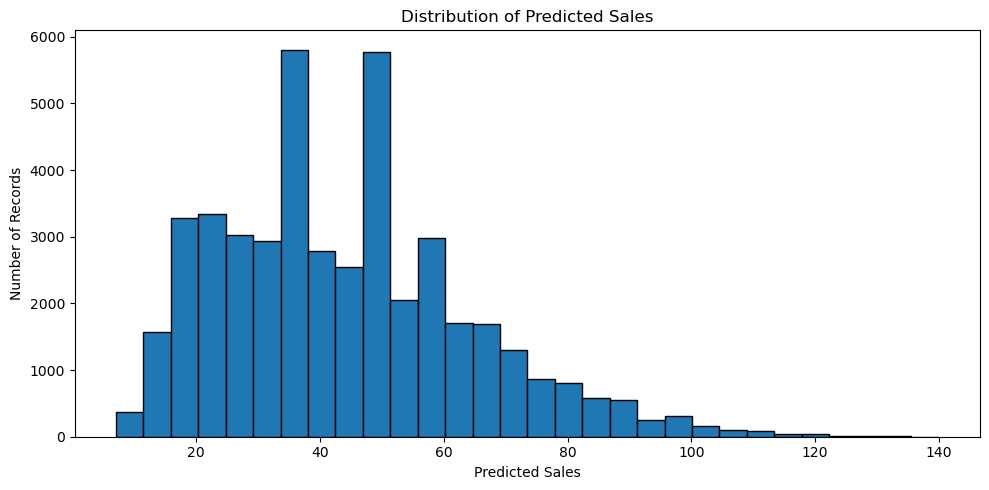

In [49]:
plt.figure(figsize=(10, 5))

plt.hist(
    forecast_results["predicted_sales"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Predicted Sales")
plt.xlabel("Predicted Sales")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

## Insight:
This shows how the predicted demand is distributed across the test data. It helps identify whether most products have low, medium, 
or high expected demand.

# Top 10 Items by Predicted Demand

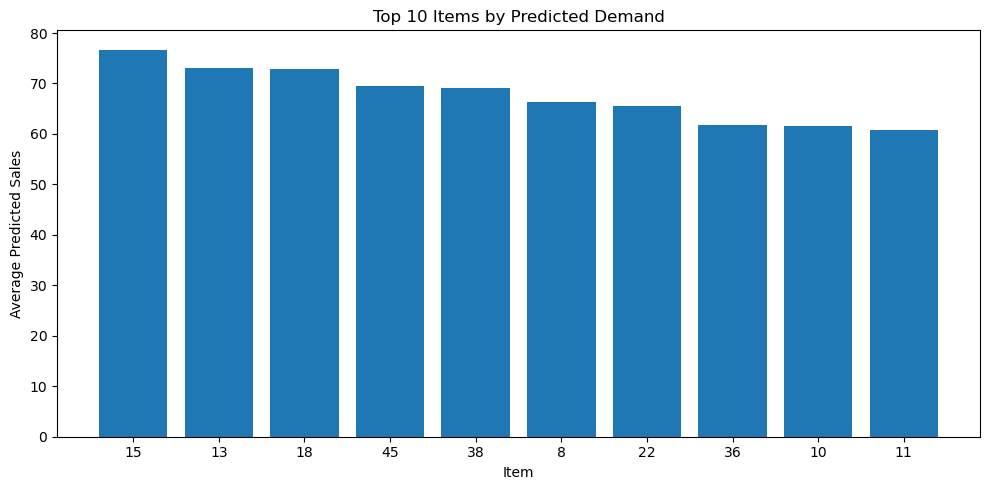

In [51]:
top_items = (
    forecast_results
    .groupby("item")["predicted_sales"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))

plt.bar(
    top_items.index.astype(str),
    top_items.values
)

plt.title("Top 10 Items by Predicted Demand")
plt.xlabel("Item")
plt.ylabel("Average Predicted Sales")

plt.tight_layout()
plt.show()

# Insight:
These are the items with the highest predicted average demand and can be given higher inventory planning priority.

# Predicted Demand by Store

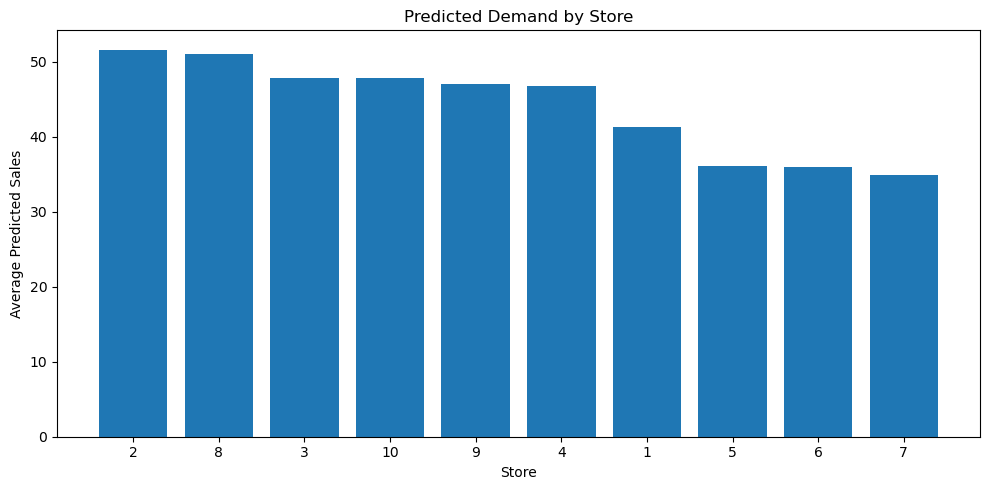

In [52]:
store_demand = (
    forecast_results
    .groupby("store")["predicted_sales"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

plt.bar(
    store_demand.index.astype(str),
    store_demand.values
)

plt.title("Predicted Demand by Store")
plt.xlabel("Store")
plt.ylabel("Average Predicted Sales")

plt.tight_layout()
plt.show()

# Insight:
This visualization compares expected demand across stores and helps identify stores that may require greater inventory allocation.

# Predicted Demand Over Time

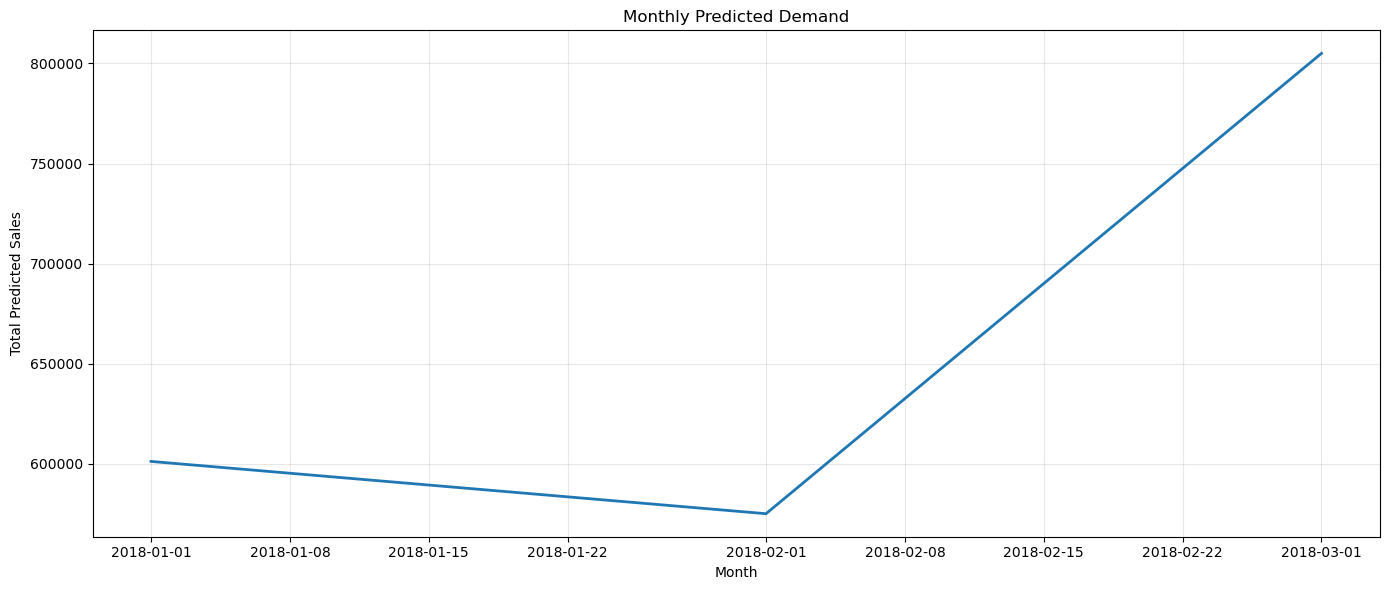

In [53]:
monthly_forecast = (
    forecast_results
    .groupby(forecast_results["date"].dt.to_period("M"))["predicted_sales"]
    .sum()
)

monthly_forecast.index = monthly_forecast.index.to_timestamp()

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_forecast.index,
    monthly_forecast.values,
    linewidth=2
)

plt.title("Monthly Predicted Demand")
plt.xlabel("Month")
plt.ylabel("Total Predicted Sales")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Insight:
This shows the expected demand trend over the forecast period and helps businesses plan inventory according to changing demand.